In [1]:
import yfinance as yf
from pandas_datareader import data as pdr

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [3]:
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

In [4]:
df = yf.download('AAPL', start, end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [5]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-05-28,189.105621,192.101605,188.219765,190.618535,52280100
2024-05-29,189.404205,191.355088,188.627837,188.727378,53068000
2024-05-30,190.399567,191.285423,189.742650,189.872035,49947900
2024-05-31,191.355103,191.673620,189.025999,190.548875,75158300
2024-06-03,193.126801,194.082338,191.623835,192.002056,50080500
...,...,...,...,...,...
2025-05-19,208.779999,209.479996,204.259995,207.910004,46140500
2025-05-20,206.860001,208.470001,205.029999,207.669998,42496600


In [6]:
df = df.droplevel([1], axis=1)
df['company_name'] = 'AAPL'

In [7]:
df

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2024-05-28,189.105621,192.101605,188.219765,190.618535,52280100,AAPL
2024-05-29,189.404205,191.355088,188.627837,188.727378,53068000,AAPL
2024-05-30,190.399567,191.285423,189.742650,189.872035,49947900,AAPL
2024-05-31,191.355103,191.673620,189.025999,190.548875,75158300,AAPL
2024-06-03,193.126801,194.082338,191.623835,192.002056,50080500,AAPL
...,...,...,...,...,...,...
2025-05-19,208.779999,209.479996,204.259995,207.910004,46140500,AAPL
2025-05-20,206.860001,208.470001,205.029999,207.669998,42496600,AAPL
2025-05-21,202.089996,207.039993,200.710007,205.169998,59211800,AAPL


In [8]:
stock_price_t = []

company_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
company_name = ['APPLE', 'GOOGLE', 'MICROSOFT', 'AMAZON']

for company, com_name in zip(company_list, company_name):
    df = yf.download(company, start, end)
    df['company_name'] = com_name
    df = df.droplevel([1], axis=1)
    stock_price_t.append(df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
df = pd.concat(stock_price_t, axis=0)
df.tail(10)

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-05-12,208.639999,211.660004,205.750000,210.710007,75205000,AMAZON
2025-05-13,211.369995,214.839996,210.100006,211.080002,56193700,AMAZON
2025-05-14,210.250000,211.929993,208.850006,211.449997,38492100,AMAZON
2025-05-15,205.169998,206.880005,202.669998,206.449997,64347300,AMAZON
2025-05-16,205.589996,206.850006,204.369995,206.850006,43318500,AMAZON
2025-05-19,206.160004,206.619995,201.259995,201.649994,34314800,AMAZON
2025-05-20,204.070007,205.589996,202.649994,204.630005,29470400,AMAZON
2025-05-21,201.119995,203.460007,200.059998,201.610001,42460900,AMAZON
2025-05-22,203.100006,205.759995,200.160004,201.380005,38938900,AMAZON


In [10]:
df[df['company_name'] == 'APPLE'].describe()

Price,Close,High,Low,Open,Volume
count,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,222.933558,225.208541,220.218315,222.545678,5.629998e+07
std,15.582621,15.098329,16.009114,15.781932,3.246264e+07
min,172.194199,190.090729,168.988411,171.724805,2.323470e+07
25%,213.210419,215.741063,210.615041,212.934166,3.970720e+07
50%,224.458542,226.104564,222.238802,224.199183,4.807340e+07
75%,232.582443,234.316353,229.187143,232.502737,6.040290e+07
max,258.396667,259.474086,257.010028,257.568678,3.186799e+08


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 996 entries, 2024-05-28 to 2025-05-23
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         996 non-null    float64
 1   High          996 non-null    float64
 2   Low           996 non-null    float64
 3   Open          996 non-null    float64
 4   Volume        996 non-null    int64  
 5   company_name  996 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 54.5+ KB


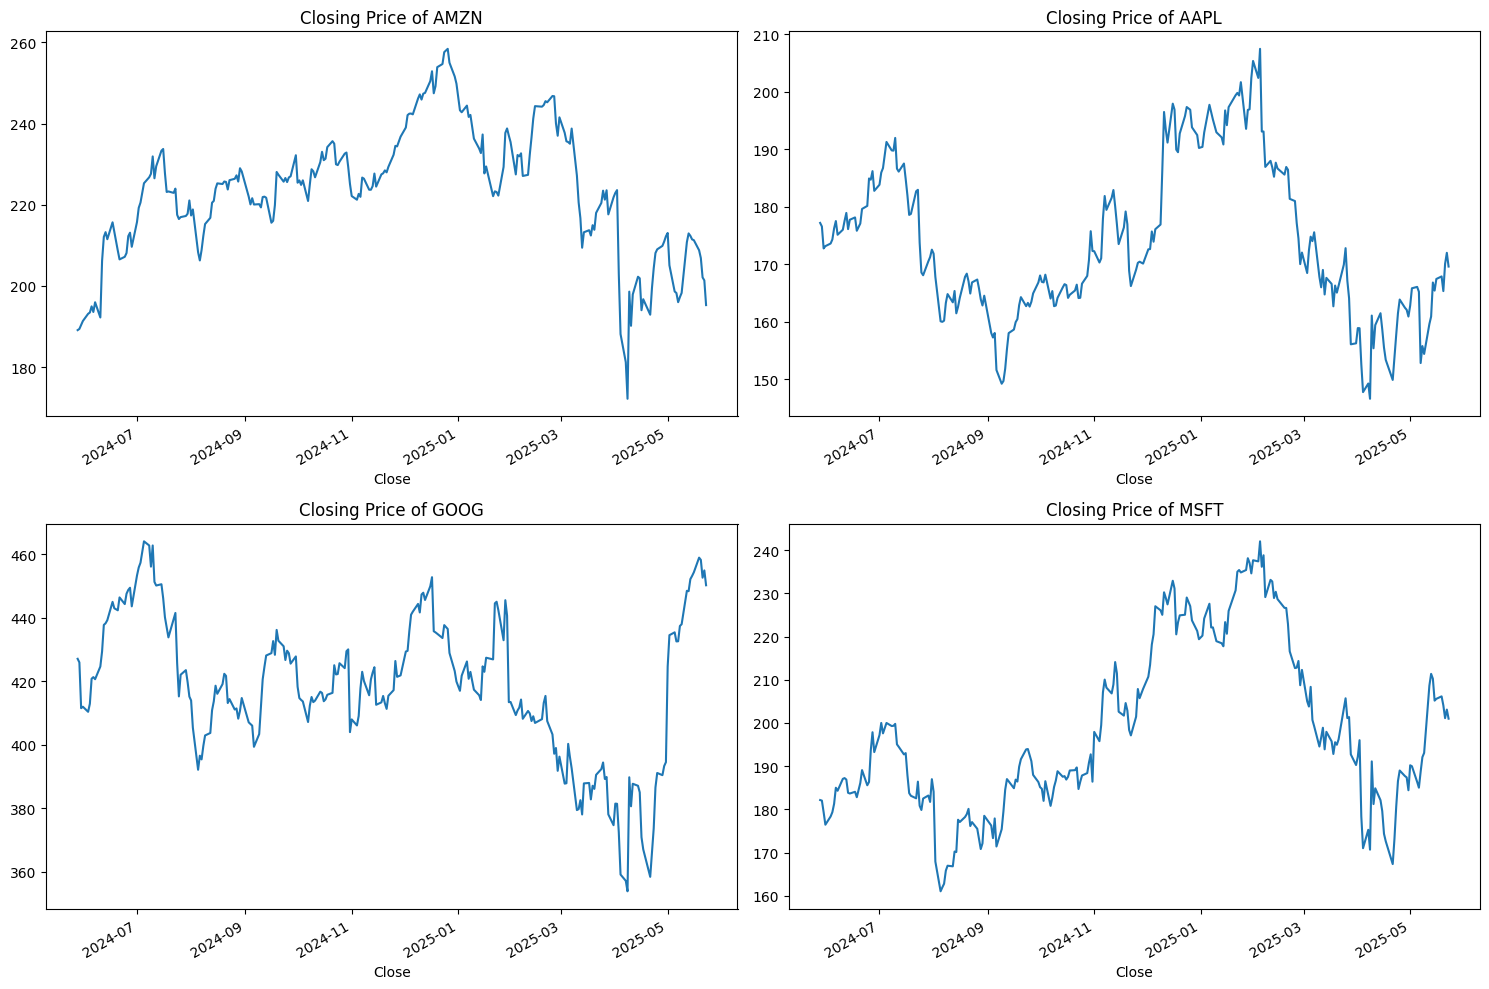

In [12]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_name):
    plt.subplot(2, 2, i+1)
    df[df['company_name'] == company]['Close'].plot()
    plt.xlabel('Close')
    plt.ylabel(None)
    plt.title(f"Closing Price of {tech_list[i-1]}")

plt.tight_layout()

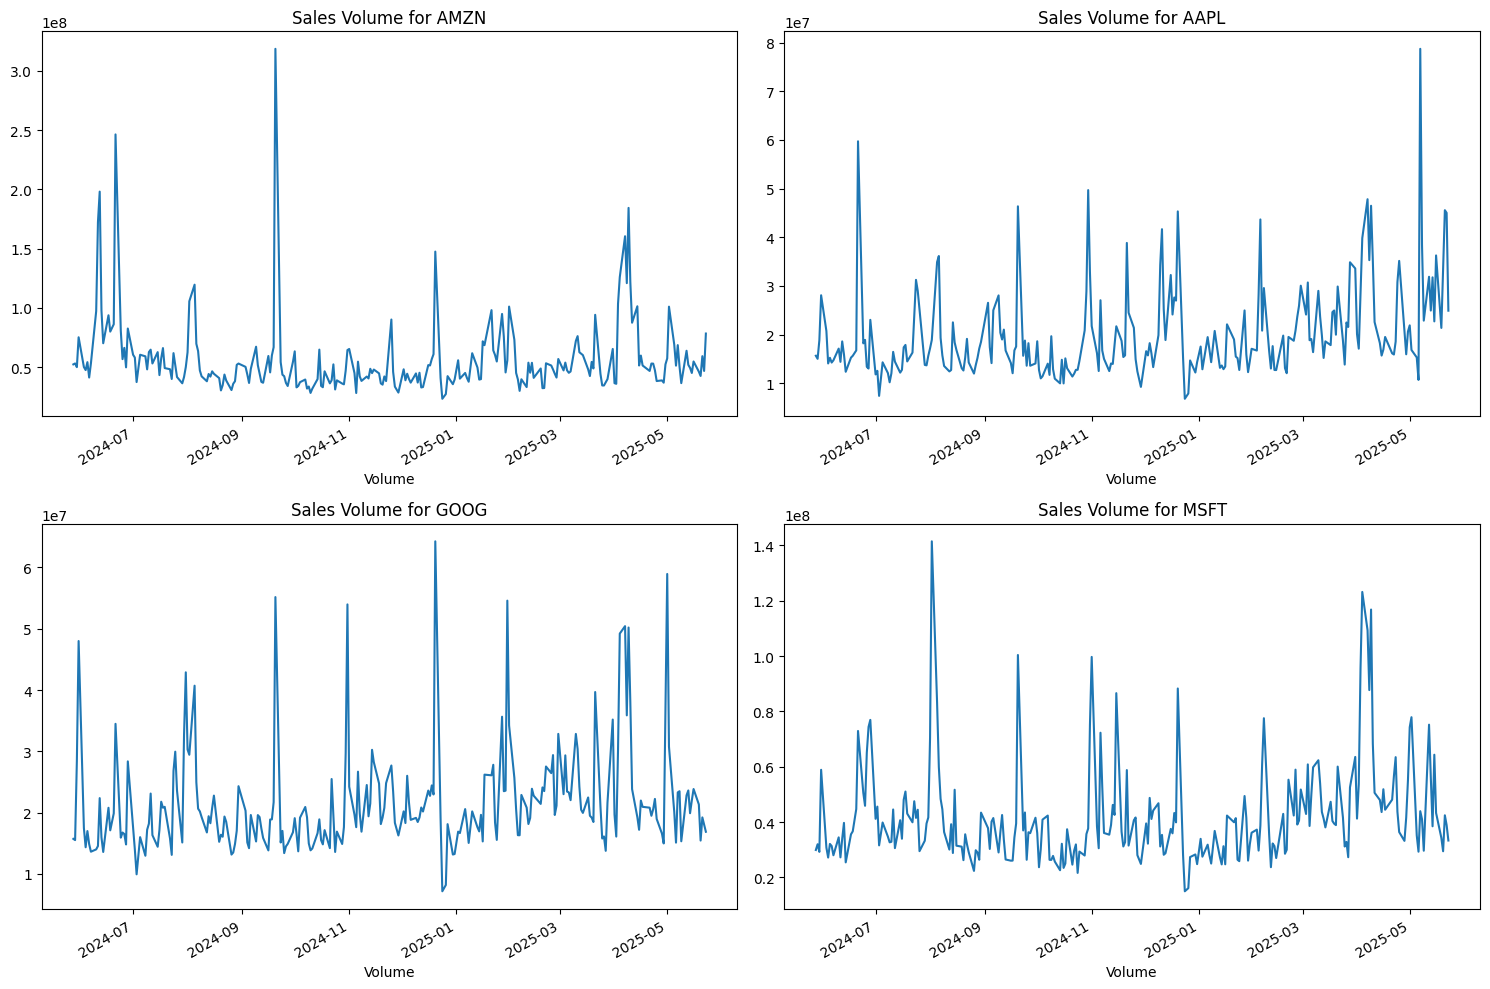

In [13]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_name):
    plt.subplot(2, 2, i+1)
    df[df['company_name'] == company]['Volume'].plot()
    plt.xlabel('Volume')
    plt.ylabel(None)
    plt.title(f"Sales Volume for {tech_list[i-1]}")

plt.tight_layout()

In [14]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_name:
        column_name = f"MA for {ma} days"

        if not ("df_ma_" + str(ma) in globals()):
            globals()["df_ma_" + str(ma)] = pd.DataFrame()

        globals()["df_ma_" + str(ma)][company] = (
            df[df['company_name'] == company]["Close"]
            .rolling(ma, on=df.index, min_periods=ma)
            .mean()
        )

In [15]:
df_ma_10.head(11)

,APPLE,GOOGLE,MICROSOFT,AMAZON
Date,,,,
2024-05-28,NaN,NaN,NaN,NaN
2024-05-29,NaN,NaN,NaN,NaN
2024-05-30,NaN,NaN,NaN,NaN
2024-05-31,NaN,NaN,NaN,NaN
2024-06-03,NaN,NaN,NaN,NaN
2024-06-04,NaN,NaN,NaN,NaN
2024-06-05,NaN,NaN,NaN,NaN
2024-06-06,NaN,NaN,NaN,NaN
2024-06-07,NaN,NaN,NaN,NaN


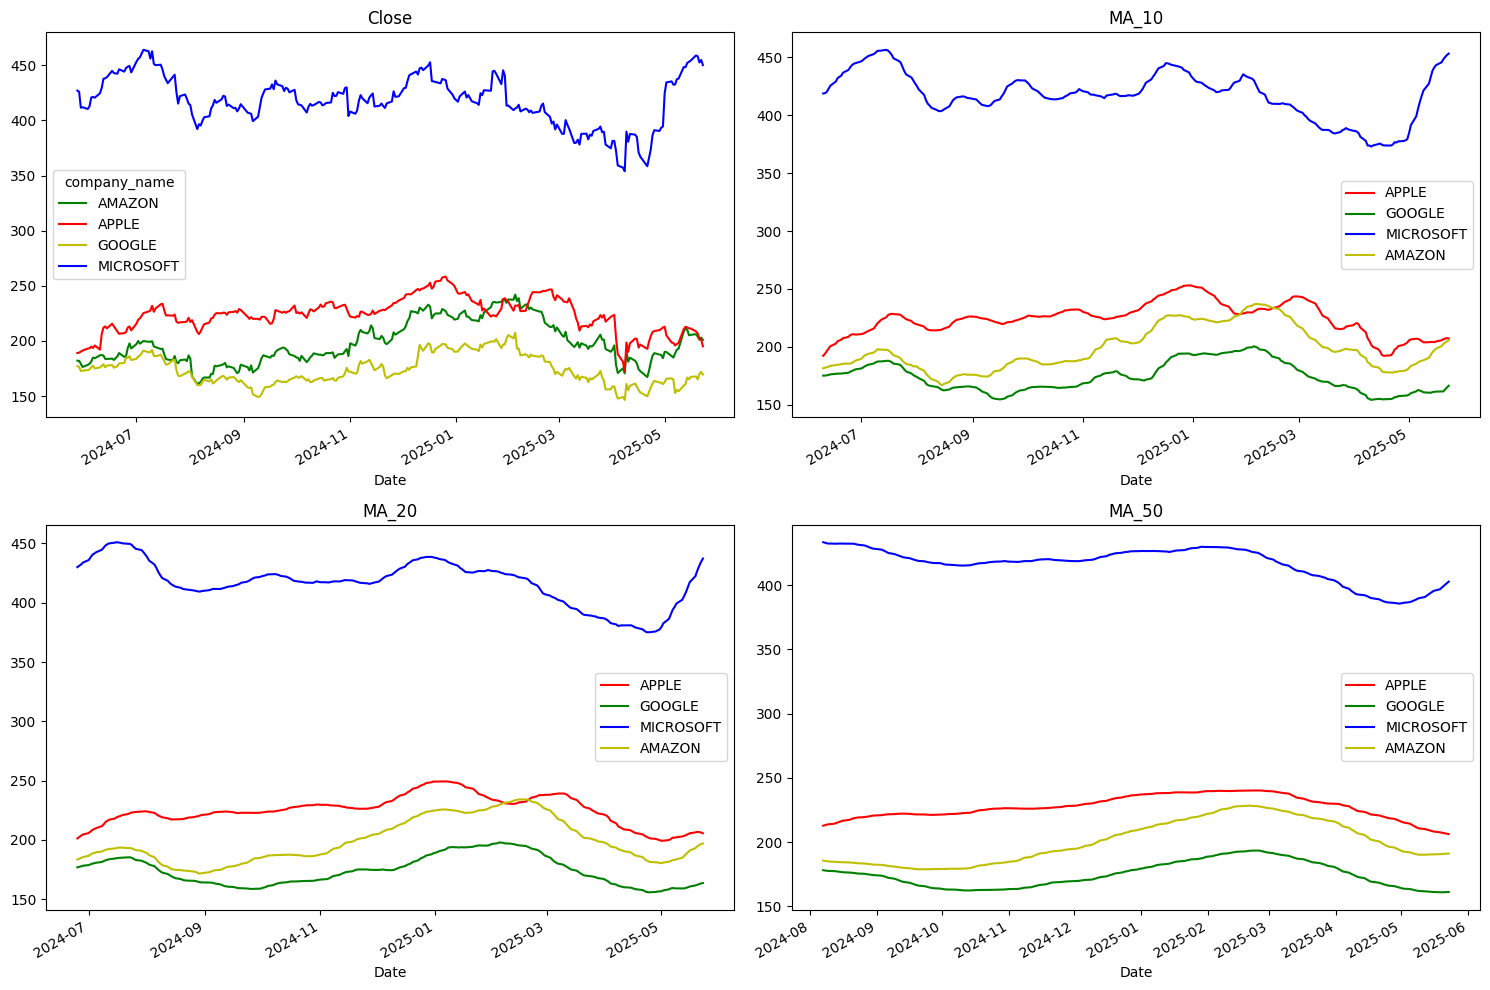

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

df.pivot_table(index="Date", values=["Close"], columns=["company_name"]).droplevel(
    [0], axis=1
).plot(ax=axes[0, 0], color=["g", "r", "y", "b"])
axes[0, 0].set_title("Close")

df_ma_10.plot(ax=axes[0, 1], color=["r", "g", "b", "y"])
axes[0, 1].set_title("MA_10")

df_ma_20.plot(ax=axes[1, 0], color=["r", "g", "b", "y"])
axes[1, 0].set_title("MA_20")

df_ma_50.plot(ax=axes[1, 1], color=["r", "g", "b", "y"])
axes[1, 1].set_title("MA_50")

fig.tight_layout()

In [20]:
df_apple = pd.DataFrame(
    index=df[df["company_name"] == "APPLE"].index,
    columns=["Close", "ma_10", "ma_20", "ma_50"],
    data={
        "Close": df[df["company_name"] == "APPLE"]["Close"],
        "ma_10": df_ma_10["APPLE"],
        "ma_20": df_ma_20["APPLE"],
        "ma_50": df_ma_50["APPLE"]
    }
)

df_apple

,Close,ma_10,ma_20,ma_50
Date,,,,
2024-05-28,189.105606,NaN,NaN,NaN
2024-05-29,189.404221,NaN,NaN,NaN
2024-05-30,190.399567,NaN,NaN,NaN
2024-05-31,191.355087,NaN,NaN,NaN
2024-06-03,193.126801,NaN,NaN,NaN
...,...,...,...,...
2025-05-19,208.779999,205.728435,206.398450,207.628971
2025-05-20,206.860001,206.589433,206.767529,207.222529
2025-05-21,202.089996,207.199135,206.655425,206.853313


In [21]:
df_amazon = pd.DataFrame(
    index=df[df["company_name"] == "AMAZON"].index,
    columns=["Close", "ma_10", "ma_20", "ma_50"],
    data={
        "Close": df[df["company_name"] == "AMAZON"]["Close"],
        "ma_10": df_ma_10["AMAZON"],
        "ma_20": df_ma_20["AMAZON"],
        "ma_50": df_ma_50["AMAZON"]
    }
)

df_google = pd.DataFrame(
    index=df[df["company_name"] == "GOOGLE"].index,
    columns=["Close", "ma_10", "ma_20", "ma_50"],
    data={
        "Close": df[df["company_name"] == "GOOGLE"]["Close"],
        "ma_10": df_ma_10["GOOGLE"],
        "ma_20": df_ma_20["GOOGLE"],
        "ma_50": df_ma_50["GOOGLE"]
    }
)

df_ms = pd.DataFrame(
    index=df[df["company_name"] == "MICROSOFT"].index,
    columns=["Close", "ma_10", "ma_20", "ma_50"],
    data={
        "Close": df[df["company_name"] == "MICROSOFT"]["Close"],
        "ma_10": df_ma_10["MICROSOFT"],
        "ma_20": df_ma_20["MICROSOFT"],
        "ma_50": df_ma_50["MICROSOFT"]
    }
)

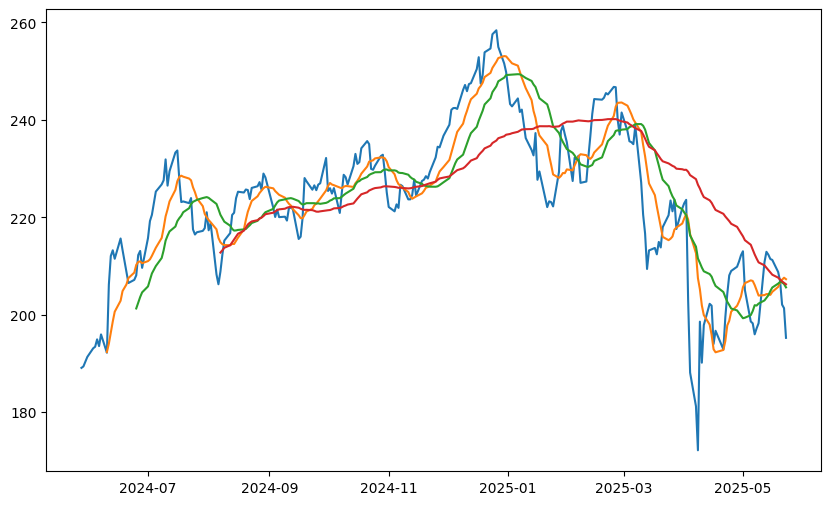

In [22]:
plt.figure(figsize=(10,6))
plt.plot(df_apple)
plt.show()

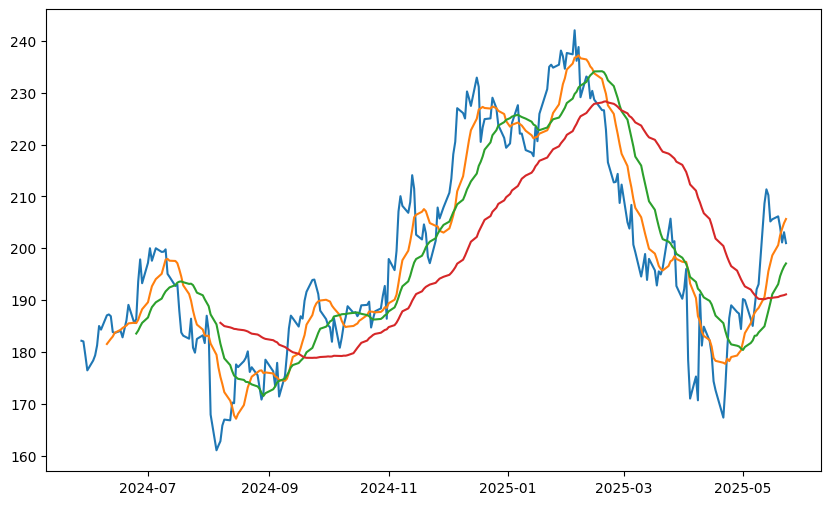

In [23]:
plt.figure(figsize=(10,6))
plt.plot(df_amazon)
plt.show()

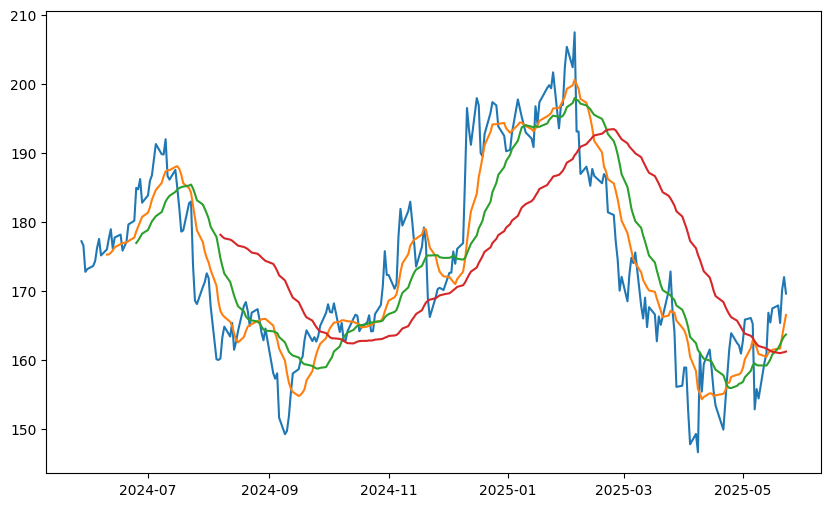

In [24]:
plt.figure(figsize=(10,6))
plt.plot(df_google)
plt.show()

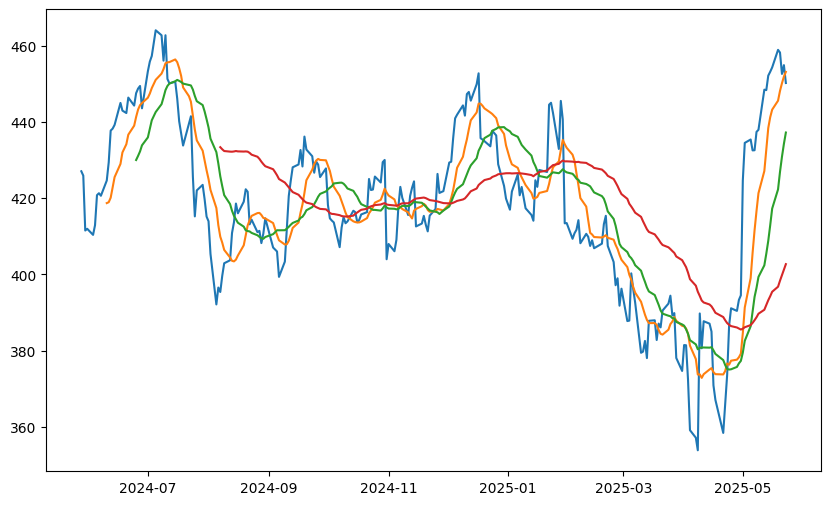

In [25]:
plt.figure(figsize=(10,6))
plt.plot(df_ms)
plt.show()

In [26]:
dfs = [df_amazon, df_apple, df_google, df_ms]
for df in dfs:
    df["Daily Return"] = df["Close"].pct_change()

In [27]:
df_google

,Close,ma_10,ma_20,ma_50,Daily Return
Date,,,,,
2024-05-28,177.180786,NaN,NaN,NaN,NaN
2024-05-29,176.563690,NaN,NaN,NaN,-0.003483
2024-05-30,172.741821,NaN,NaN,NaN,-0.021646
2024-05-31,173.139938,NaN,NaN,NaN,0.002305
2024-06-03,173.597778,NaN,NaN,NaN,0.002644
...,...,...,...,...,...
2025-05-19,167.869995,161.610999,161.653499,160.997799,0.002628
2025-05-20,165.320007,161.623000,162.224500,160.947999,-0.015190
2025-05-21,170.059998,163.348999,162.841499,161.029599,0.028672


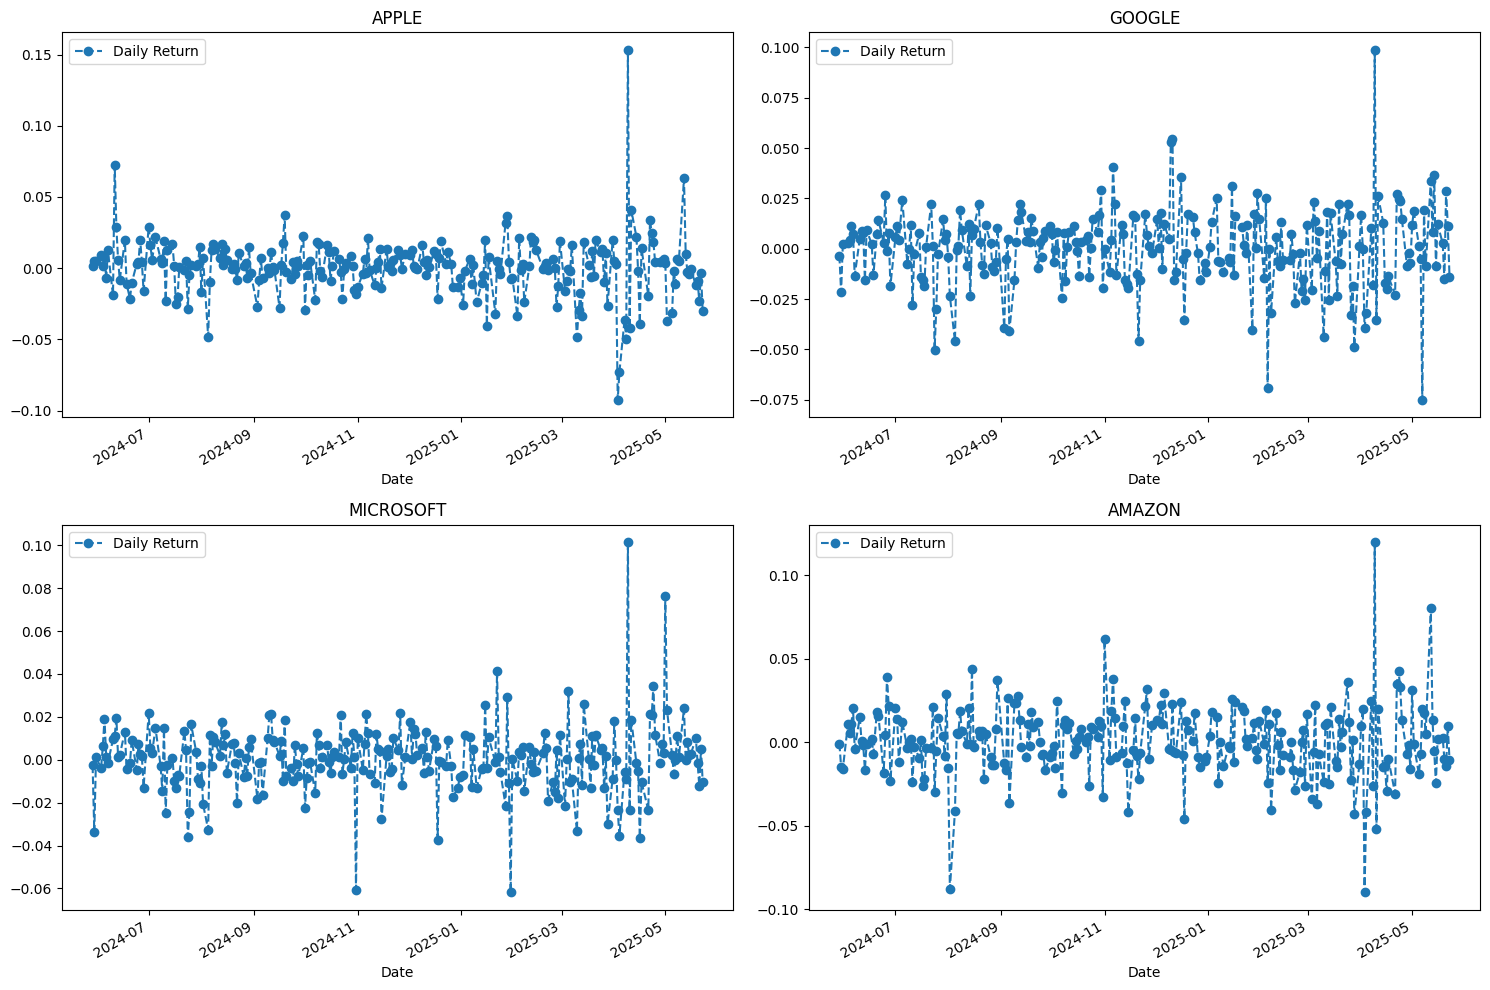

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

df_apple["Daily Return"].plot(ax=axes[0, 0], legend=True, linestyle="--", marker="o")
axes[0, 0].set_title("APPLE")

df_google["Daily Return"].plot(ax=axes[0, 1], legend=True, linestyle="--", marker="o")
axes[0, 1].set_title("GOOGLE")

df_ms["Daily Return"].plot(ax=axes[1, 0], legend=True, linestyle="--", marker="o")
axes[1, 0].set_title("MICROSOFT")

df_amazon["Daily Return"].plot(ax=axes[1, 1], legend=True, linestyle="--", marker="o")
axes[1, 1].set_title("AMAZON")

fig.tight_layout()

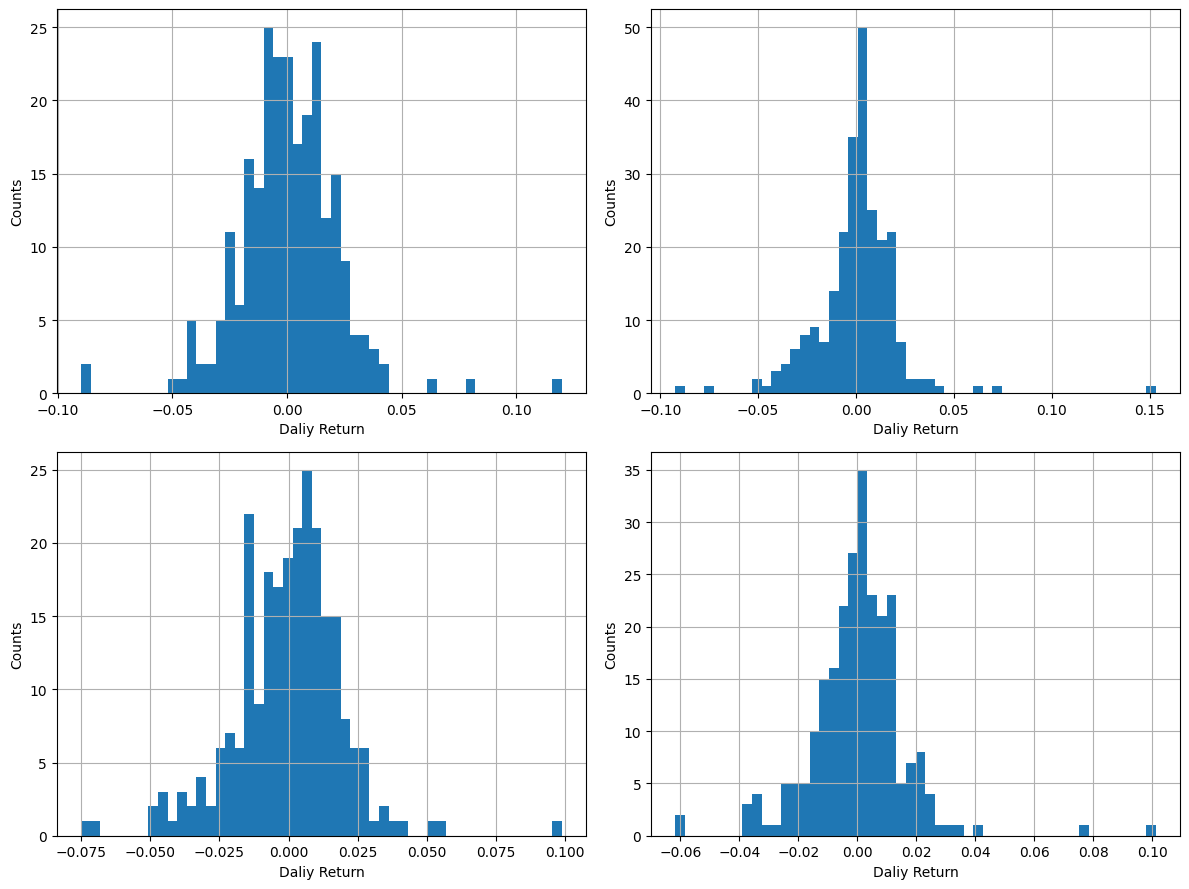

In [31]:
plt.figure(figsize=(12, 9))

for i, df in enumerate(dfs, 1):
    plt.subplot(2, 2, i)
    df["Daily Return"].hist(bins=50)
    plt.xlabel("Daliy Return")
    plt.ylabel("Counts")

plt.tight_layout()

In [32]:
df = yf.download("AAPL", start="2012-01-01", end=datetime.now()).droplevel([1], axis=1)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,12.359185,12.397355,12.292165,12.304187,302220800
2012-01-04,12.425599,12.462867,12.300574,12.322213,260022000
2012-01-05,12.563554,12.579182,12.402463,12.470987,271269600
2012-01-06,12.694885,12.705404,12.599313,12.615843,318292800
2012-01-09,12.674749,12.855676,12.663329,12.788054,394024400
...,...,...,...,...,...
2025-05-19,208.779999,209.479996,204.259995,207.910004,46140500
2025-05-20,206.860001,208.470001,205.029999,207.669998,42496600
2025-05-21,202.089996,207.039993,200.710007,205.169998,59211800


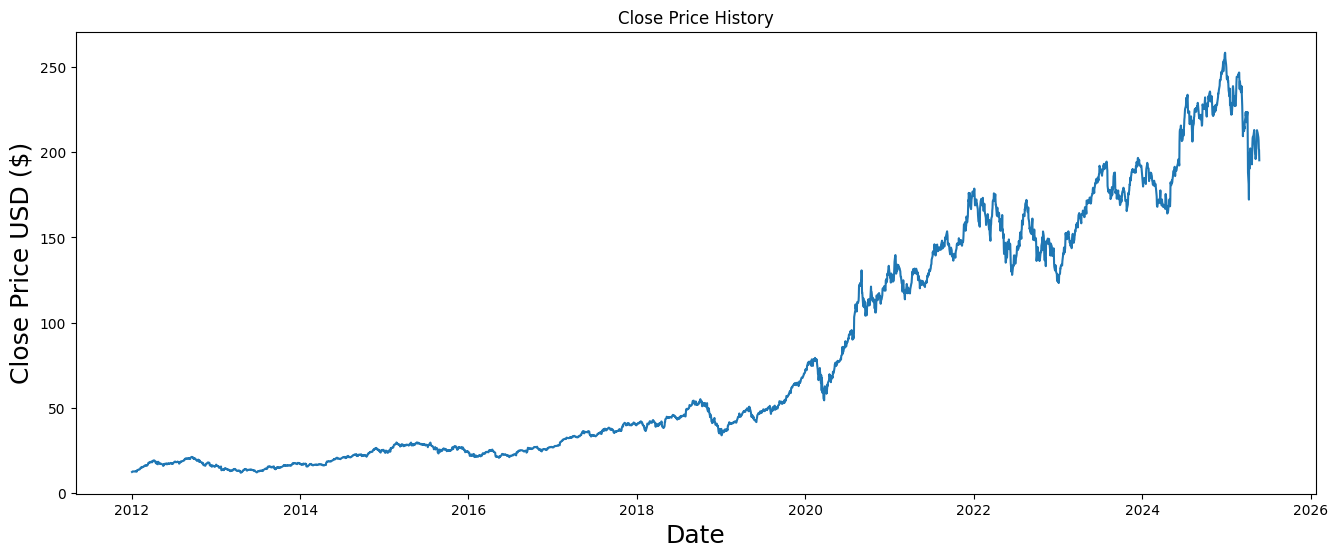

In [33]:
plt.figure(figsize=(16, 6))
plt.title("Close Price History")
plt.plot(df["Close"])
plt.xlabel("Date", fontsize=18)
plt.ylabel("Close Price USD ($)", fontsize=18)
plt.show()

In [34]:
data = df.filter(["Close"])
dataset = data.values
training_data_len = int(np.ceil(len(dataset) * 0.95))

training_data_len

3200

In [35]:
data

,Close
Date,
2012-01-03,12.359185
2012-01-04,12.425599
2012-01-05,12.563554
2012-01-06,12.694885
2012-01-09,12.674749
...,...
2025-05-19,208.779999
2025-05-20,206.860001
2025-05-21,202.089996


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00182112],
       [0.00209056],
       [0.00265025],
       ...,
       [0.77156273],
       [0.76860113],
       [0.74389389]])

In [37]:
train_data = scaled_data[0 : int(training_data_len), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i - 60 : i, 0])
    y_train.append(train_data[i, 0])
    if i <= 61:
        print(x_train)
        print(y_train)
        print()

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

[array([0.00182112, 0.00209056, 0.00265025, 0.00318306, 0.00310137,
       0.00328549, 0.00320137, 0.00305991, 0.00286728, 0.00346352,
       0.00400122, 0.00383539, 0.00292701, 0.00379395, 0.00294043,
       0.00614111, 0.00589358, 0.0062167 , 0.00691535, 0.00733846,
       0.00730312, 0.00717264, 0.00772864, 0.00825172, 0.00884432,
       0.00980146, 0.0118121 , 0.01184257, 0.01296189, 0.01379832,
       0.01236079, 0.01291434, 0.01290338, 0.01445555, 0.01423483,
       0.01464331, 0.01537736, 0.01578581, 0.01696246, 0.01781958,
       0.01806712, 0.01815371, 0.01668811, 0.01633451, 0.01638695,
       0.01776474, 0.01815247, 0.01898525, 0.02094835, 0.0235674 ,
       0.02307726, 0.02307847, 0.02497204, 0.02556464, 0.02514272,
       0.02475745, 0.02435627, 0.02568902, 0.02660346, 0.02698636])]
[0.026040134653882288]

[array([0.00182112, 0.00209056, 0.00265025, 0.00318306, 0.00310137,
       0.00328549, 0.00320137, 0.00305991, 0.00286728, 0.00346352,
       0.00400122, 0.00383539, 0.0

In [38]:
x_train.shape, y_train.shape

((3140, 60, 1), (3140,))

In [40]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.fit(x_train, y_train, batch_size=1, epochs=1)

I0000 00:00:1748226052.290496   13190 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4724 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/kth/venv/mp_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1748226054.670565   38304 cuda_dnn.cc:529] Loaded cuDNN version 90300


3140/3140 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0022


In [42]:
test_data = scaled_data[training_data_len - 60:, :]

x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    print(f"{i}nd(st) data from {i-60} to {i}")
    x_test.append(test_data[i-60 : i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

60nd(st) data from 0 to 60
61nd(st) data from 1 to 61
62nd(st) data from 2 to 62
63nd(st) data from 3 to 63
64nd(st) data from 4 to 64
65nd(st) data from 5 to 65
66nd(st) data from 6 to 66
67nd(st) data from 7 to 67
68nd(st) data from 8 to 68
69nd(st) data from 9 to 69
70nd(st) data from 10 to 70
71nd(st) data from 11 to 71
72nd(st) data from 12 to 72
73nd(st) data from 13 to 73
74nd(st) data from 14 to 74
75nd(st) data from 15 to 75
76nd(st) data from 16 to 76
77nd(st) data from 17 to 77
78nd(st) data from 18 to 78
79nd(st) data from 19 to 79
80nd(st) data from 20 to 80
81nd(st) data from 21 to 81
82nd(st) data from 22 to 82
83nd(st) data from 23 to 83
84nd(st) data from 24 to 84
85nd(st) data from 25 to 85
86nd(st) data from 26 to 86
87nd(st) data from 27 to 87
88nd(st) data from 28 to 88
89nd(st) data from 29 to 89
90nd(st) data from 30 to 90
91nd(st) data from 31 to 91
92nd(st) data from 32 to 92
93nd(st) data from 33 to 93
94nd(st) data from 34 to 94
95nd(st) data from 35 to 95
96

8.583927254496393

/tmp/ipykernel_13190/1230126753.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


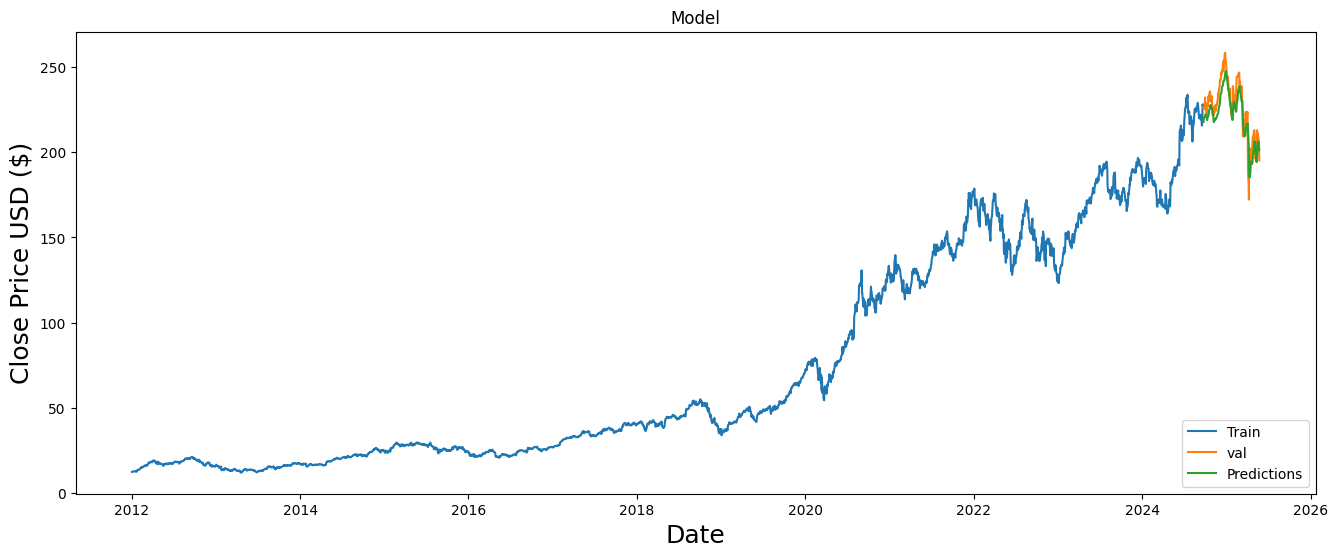

In [44]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid["Predictions"] = predictions

plt.figure(figsize=(16, 6))
plt.title("Model")
plt.xlabel("Date", fontsize=18)
plt.ylabel("Close Price USD ($)", fontsize=18)
plt.plot(train["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Train", "val", "Predictions"], loc="lower right")
plt.show()

In [45]:
valid.tail(20)

,Close,Predictions
Date,,
2025-04-28,209.864792,200.052490
2025-04-29,210.933395,202.124435
2025-04-30,212.221710,203.807983
2025-05-01,213.040634,205.221863
2025-05-02,205.081070,206.368439
2025-05-05,198.629532,205.410950
2025-05-06,198.250015,202.586761
2025-05-07,195.992981,199.666428
2025-05-08,197.231369,196.853531
